In [49]:
import pickle

pickle.dump(model, open("delivery_model.pkl", "wb"))

importing the lib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

EDA

In [2]:
df=pd.read_csv('D:\data\Cd\ML\LinearReg\Food_Delivery_Times.csv')

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


shape: used to give rows and col

In [4]:
df.shape

(1000, 9)

info : used to give info of dtypes and null val

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


columns: shows no of col in dataset

In [6]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

describe : gives mean median and mode inshort statistics

In [7]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


Step 2 Finding Null Values

In [8]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [ ]:
# this piece of code cant run because 
# weather,traffic_level and time_of_day are categorical features and we cant find median of categorical features
# so we have to do mode 


for col in [
    'Weather',
    'Traffic_level',
    'Time_of_day',
    'Courier_Experience_yrs'
]:
    df[col].fillna(df[col].median(),inplace=True)

TypeError: Cannot convert ['Windy' 'Clear' 'Foggy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear' 'Snowy'
 'Foggy' 'Snowy' 'Clear' 'Clear' 'Rainy' 'Clear' 'Snowy' 'Rainy' 'Snowy'
 'Foggy' 'Clear' 'Rainy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear' 'Windy'
 'Snowy' 'Snowy' 'Clear' 'Clear' 'Rainy' 'Clear' 'Foggy' 'Windy' 'Snowy'
 'Clear' 'Windy' 'Clear' 'Rainy' 'Rainy' 'Clear' nan 'Clear' 'Snowy'
 'Windy' 'Snowy' 'Clear' 'Rainy' 'Clear' 'Rainy' 'Rainy' 'Snowy' 'Rainy'
 'Windy' 'Clear' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear' 'Windy' 'Rainy'
 'Windy' 'Clear' 'Clear' 'Windy' 'Clear' 'Clear' 'Clear' 'Snowy' nan
 'Rainy' 'Snowy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Snowy' 'Foggy' 'Rainy'
 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Snowy'
 'Windy' 'Rainy' 'Clear' 'Rainy' 'Rainy' 'Clear' 'Clear' 'Windy' 'Clear'
 'Clear' 'Clear' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Snowy'
 'Clear' 'Rainy' 'Foggy' 'Snowy' 'Clear' 'Clear' 'Rainy' 'Clear' 'Clear'
 'Foggy' 'Clear' 'Foggy' 'Foggy' 'Windy' 'Clear' 'Clear' 'Clear' 'Windy'
 'Clear' 'Clear' 'Clear' 'Windy' 'Foggy' 'Rainy' 'Clear' 'Rainy' 'Rainy'
 'Clear' 'Foggy' 'Clear' 'Clear' 'Clear' 'Foggy' 'Clear' 'Clear' 'Snowy'
 'Clear' 'Clear' 'Rainy' 'Snowy' 'Rainy' 'Clear' 'Rainy' 'Foggy' 'Clear'
 nan 'Clear' 'Clear' 'Foggy' 'Clear' 'Foggy' 'Clear' 'Rainy' 'Clear'
 'Snowy' 'Clear' 'Windy' 'Clear' 'Rainy' nan nan 'Clear' 'Clear' 'Clear'
 'Foggy' 'Snowy' 'Clear' 'Rainy' 'Rainy' 'Rainy' 'Clear' 'Clear' 'Rainy'
 'Clear' 'Rainy' 'Clear' 'Clear' 'Clear' 'Foggy' 'Clear' 'Snowy' 'Clear'
 'Clear' 'Clear' 'Rainy' 'Clear' 'Snowy' 'Rainy' 'Clear' 'Clear' 'Clear'
 'Clear' 'Foggy' 'Clear' 'Clear' nan 'Clear' 'Clear' 'Foggy' 'Clear'
 'Rainy' 'Rainy' 'Snowy' 'Clear' 'Clear' 'Windy' 'Windy' 'Snowy' 'Windy'
 'Rainy' 'Clear' 'Rainy' 'Foggy' 'Clear' 'Windy' 'Clear' 'Rainy' nan
 'Windy' 'Foggy' 'Snowy' 'Clear' nan 'Snowy' 'Clear' 'Clear' 'Clear'
 'Rainy' 'Clear' 'Clear' 'Clear' 'Windy' 'Snowy' 'Clear' 'Clear' 'Clear'
 'Snowy' 'Clear' 'Clear' 'Rainy' 'Windy' 'Clear' 'Clear' 'Clear' 'Rainy'
 'Rainy' 'Rainy' 'Clear' 'Windy' nan 'Rainy' 'Rainy' 'Rainy' 'Clear'
 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear'
 'Clear' 'Rainy' 'Snowy' 'Clear' 'Clear' 'Windy' 'Clear' 'Clear' 'Rainy'
 'Clear' nan 'Clear' 'Clear' 'Clear' 'Rainy' 'Rainy' 'Rainy' 'Clear'
 'Clear' 'Clear' 'Snowy' 'Clear' 'Windy' 'Rainy' 'Foggy' 'Foggy' 'Rainy'
 'Foggy' 'Snowy' 'Clear' 'Windy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Windy'
 'Clear' 'Rainy' 'Clear' 'Snowy' 'Clear' 'Clear' 'Clear' 'Windy' 'Rainy'
 'Windy' 'Clear' 'Foggy' 'Clear' 'Windy' 'Foggy' 'Clear' 'Clear' 'Clear'
 'Rainy' 'Foggy' 'Clear' 'Clear' 'Clear' 'Rainy' 'Foggy' 'Clear' 'Clear'
 'Clear' 'Rainy' 'Rainy' 'Rainy' 'Rainy' 'Snowy' 'Snowy' 'Rainy' 'Rainy'
 nan 'Clear' 'Clear' 'Foggy' 'Clear' 'Windy' 'Clear' 'Clear' 'Clear'
 'Snowy' nan 'Clear' 'Clear' 'Clear' 'Windy' 'Clear' 'Clear' 'Clear'
 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Windy' 'Rainy' 'Windy' 'Foggy'
 'Clear' 'Clear' 'Foggy' 'Clear' 'Rainy' 'Clear' 'Snowy' 'Clear' 'Clear'
 'Clear' 'Windy' 'Foggy' 'Rainy' 'Rainy' 'Windy' 'Clear' 'Rainy' 'Clear'
 'Snowy' 'Snowy' 'Windy' 'Snowy' 'Clear' 'Rainy' 'Clear' 'Snowy' 'Clear'
 'Rainy' 'Clear' 'Clear' 'Windy' 'Clear' 'Rainy' 'Rainy' 'Rainy' 'Clear'
 'Rainy' 'Clear' 'Rainy' 'Rainy' 'Rainy' nan 'Windy' 'Clear' 'Snowy'
 'Clear' 'Rainy' 'Rainy' 'Clear' 'Foggy' 'Windy' 'Windy' 'Clear' 'Rainy'
 'Rainy' 'Windy' 'Foggy' 'Windy' 'Windy' 'Snowy' 'Rainy' 'Windy' 'Clear'
 'Rainy' 'Clear' 'Windy' 'Rainy' 'Clear' 'Foggy' 'Rainy' 'Windy' 'Snowy'
 'Clear' 'Clear' 'Clear' 'Rainy' 'Snowy' 'Snowy' 'Foggy' 'Foggy' 'Clear'
 'Foggy' 'Rainy' 'Snowy' 'Windy' 'Windy' 'Clear' 'Foggy' 'Foggy' 'Clear'
 'Windy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Windy' 'Rainy' 'Clear' 'Clear'
 'Rainy' 'Foggy' 'Rainy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear' 'Rainy'
 'Rainy' 'Clear' 'Rainy' 'Clear' 'Windy' 'Clear' nan 'Rainy' 'Clear'
 'Clear' 'Rainy' 'Clear' 'Rainy' 'Clear' 'Windy' 'Clear' 'Clear' 'Snowy'
 'Foggy' 'Clear' 'Foggy' 'Rainy' 'Clear' 'Clear' 'Foggy' 'Foggy' 'Rainy'
 'Clear' 'Clear' 'Clear' 'Rainy' nan 'Clear' 'Clear' 'Rainy' 'Windy'
 'Windy' 'Clear' nan 'Rainy' 'Clear' 'Windy' 'Windy' 'Clear' 'Rainy'
 'Clear' 'Rainy' 'Rainy' 'Snowy' 'Clear' 'Snowy' 'Rainy' 'Foggy' 'Clear'
 'Rainy' 'Clear' 'Windy' 'Clear' 'Rainy' 'Clear' 'Clear' 'Rainy' 'Clear'
 'Foggy' 'Foggy' 'Rainy' 'Foggy' nan 'Windy' 'Rainy' 'Windy' nan 'Clear'
 'Clear' 'Clear' nan 'Rainy' 'Windy' 'Clear' 'Rainy' 'Clear' 'Clear'
 'Foggy' 'Clear' 'Foggy' 'Clear' 'Clear' 'Clear' 'Clear' 'Snowy' 'Clear'
 'Clear' 'Foggy' 'Rainy' 'Rainy' 'Foggy' nan 'Clear' 'Rainy' 'Rainy'
 'Snowy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear' 'Clear' 'Foggy' 'Rainy'
 'Clear' 'Clear' 'Rainy' 'Rainy' 'Snowy' 'Windy' 'Windy' 'Foggy' 'Rainy'
 'Clear' 'Clear' 'Clear' 'Clear' 'Rainy' 'Clear' 'Foggy' 'Clear' 'Clear'
 'Rainy' 'Clear' 'Rainy' 'Windy' nan 'Windy' 'Windy' 'Rainy' 'Snowy'
 'Clear' 'Foggy' 'Foggy' 'Foggy' 'Clear' 'Rainy' 'Clear' 'Foggy' 'Foggy'
 'Windy' 'Clear' 'Snowy' 'Foggy' 'Foggy' 'Clear' 'Clear' 'Rainy' 'Foggy'
 'Clear' 'Windy' 'Rainy' 'Rainy' 'Foggy' 'Windy' 'Snowy' 'Clear' 'Snowy'
 'Clear' 'Snowy' 'Rainy' 'Clear' 'Snowy' nan 'Clear' 'Clear' 'Clear'
 'Clear' 'Windy' 'Windy' 'Clear' 'Clear' 'Windy' 'Rainy' 'Clear' 'Clear'
 'Clear' nan 'Snowy' 'Clear' 'Foggy' 'Clear' 'Clear' 'Rainy' 'Windy'
 'Rainy' 'Windy' 'Rainy' 'Rainy' 'Clear' 'Foggy' 'Clear' 'Snowy' 'Foggy'
 'Snowy' 'Rainy' 'Clear' 'Clear' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear'
 'Foggy' 'Clear' 'Clear' 'Rainy' 'Clear' 'Clear' 'Windy' 'Rainy' 'Clear'
 'Clear' 'Foggy' 'Clear' 'Rainy' nan 'Clear' 'Rainy' 'Windy' 'Windy'
 'Clear' 'Clear' 'Rainy' 'Snowy' 'Clear' 'Rainy' 'Clear' 'Clear' 'Windy'
 'Rainy' 'Clear' 'Rainy' nan 'Foggy' 'Clear' 'Rainy' 'Rainy' 'Windy'
 'Rainy' 'Clear' nan 'Clear' 'Foggy' 'Windy' 'Clear' 'Clear' 'Clear'
 'Windy' 'Rainy' 'Clear' 'Windy' 'Rainy' 'Clear' 'Clear' 'Clear' 'Clear'
 'Rainy' 'Clear' 'Foggy' 'Clear' 'Clear' 'Foggy' 'Snowy' 'Clear' 'Rainy'
 'Clear' 'Clear' 'Snowy' 'Clear' 'Snowy' 'Clear' 'Snowy' 'Clear' 'Clear'
 'Clear' 'Rainy' 'Clear' 'Rainy' 'Clear' 'Snowy' 'Foggy' 'Foggy' 'Clear'
 'Foggy' 'Clear' 'Clear' 'Foggy' 'Clear' 'Snowy' 'Snowy' 'Clear' 'Clear'
 'Rainy' 'Clear' 'Clear' 'Clear' 'Rainy' 'Rainy' 'Rainy' 'Clear' 'Rainy'
 'Clear' 'Snowy' 'Clear' 'Foggy' 'Clear' 'Clear' 'Windy' 'Clear' 'Rainy'
 'Clear' 'Snowy' 'Clear' 'Clear' 'Snowy' 'Clear' 'Rainy' 'Clear' 'Rainy'
 'Clear' 'Clear' 'Snowy' 'Windy' 'Clear' 'Clear' 'Rainy' 'Snowy' 'Rainy'
 'Clear' 'Clear' 'Clear' 'Clear' 'Snowy' 'Clear' 'Clear' 'Clear' 'Foggy'
 'Snowy' 'Clear' 'Clear' 'Clear' 'Foggy' 'Snowy' 'Rainy' nan 'Clear'
 'Clear' 'Snowy' 'Foggy' 'Rainy' 'Foggy' 'Clear' 'Rainy' 'Clear' 'Rainy'
 'Clear' 'Foggy' 'Clear' 'Foggy' 'Snowy' 'Clear' 'Windy' 'Foggy' 'Foggy'
 'Clear' 'Clear' 'Clear' 'Foggy' 'Clear' 'Snowy' 'Rainy' 'Foggy' 'Rainy'
 'Foggy' 'Clear' 'Foggy' 'Clear' 'Clear' 'Clear' 'Snowy' 'Clear' 'Clear'
 'Clear' 'Clear' 'Snowy' 'Snowy' 'Foggy' 'Clear' 'Clear' 'Clear' 'Windy'
 'Foggy' 'Clear' 'Clear' 'Snowy' 'Clear' 'Rainy' 'Clear' 'Rainy' 'Clear'
 'Clear' 'Clear' 'Snowy' 'Windy' 'Clear' 'Rainy' 'Snowy' 'Clear' 'Rainy'
 'Clear' 'Clear' 'Clear' 'Rainy' 'Rainy' 'Windy' 'Windy' 'Windy' 'Clear'
 'Clear' 'Clear' 'Clear' 'Clear' 'Rainy' 'Clear' 'Clear' 'Foggy' 'Clear'
 'Snowy' 'Clear' 'Clear' 'Clear' 'Rainy' 'Foggy' 'Clear' 'Clear' 'Snowy'
 'Snowy' 'Clear' 'Clear' 'Rainy' 'Windy' 'Clear' 'Snowy' 'Rainy' nan
 'Clear' 'Foggy' 'Clear' 'Rainy' 'Snowy' 'Clear' 'Rainy' 'Clear' 'Clear'
 'Clear' 'Foggy' 'Clear' 'Rainy' 'Clear' 'Rainy' 'Clear' 'Clear' 'Clear'
 'Rainy' 'Foggy' 'Rainy' 'Rainy' 'Snowy' 'Windy' 'Snowy' 'Clear' 'Rainy'
 'Rainy' 'Windy' 'Foggy' 'Clear' 'Clear' 'Clear' 'Snowy' 'Clear' 'Clear'
 'Clear' 'Foggy' 'Rainy' 'Foggy' 'Clear' 'Windy' 'Rainy' 'Clear' nan
 'Clear' 'Clear' 'Snowy' 'Clear' 'Clear' 'Rainy' 'Snowy' 'Clear' 'Clear'
 'Clear' 'Foggy' 'Clear' 'Clear' 'Rainy' 'Rainy' nan 'Windy' 'Clear'
 'Rainy' 'Windy' 'Clear' 'Clear' 'Rainy' 'Snowy' 'Clear' 'Foggy'] to numeric

In [ ]:
# for categorical features we have to fill the missing values with mode
for col in [
    'Weather',
    'Traffic_Level',
    'Time_of_Day'
]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# for numerical feature median can be used to fill the missing values and for categorical features mode can be used to fill the missing values
for col in [
    
    'Courier_Experience_yrs'
]:
    df[col].fillna(df[col].median(),inplace=True)

C:\Users\Kulde\AppData\Local\Temp\ipykernel_22636\2053458418.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [26]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

Step 3 Distribution of Target Var

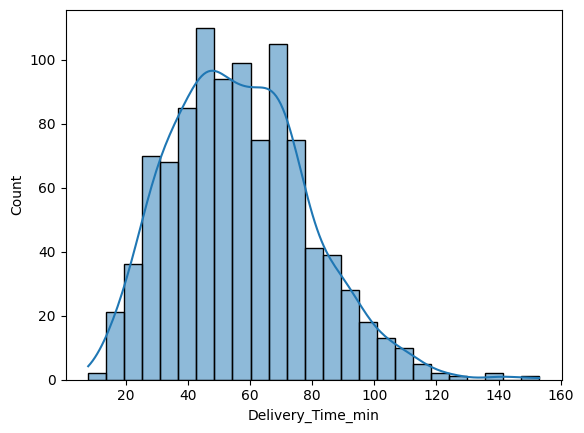

In [29]:
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.show()

"The target variable Delivery_Time_min exhibits a slightly right-skewed distribution, with most delivery times ranging between 40 and 70 minutes. A small number of observations have significantly higher delivery times, indicating potential outliers that will be further examined using boxplots."

Step 4 Correlation Analyis

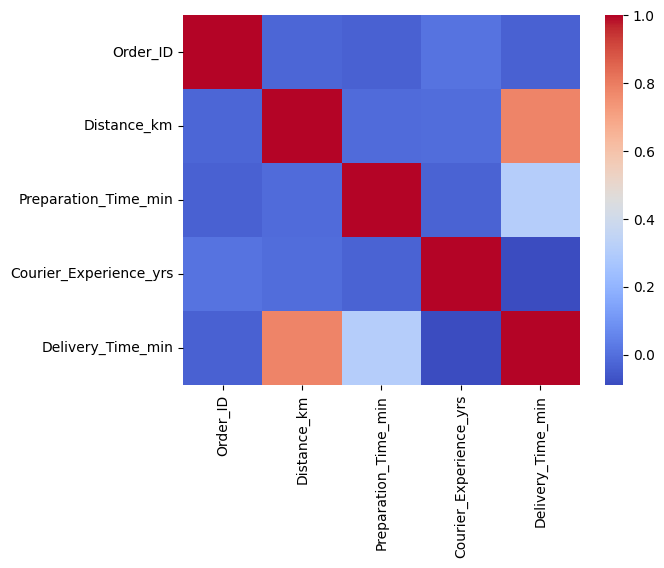

In [30]:
corr=df.select_dtypes(include='number').corr()
sns.heatmap(corr,cmap='coolwarm')
plt.show()

Step 5 Scatter Plot 


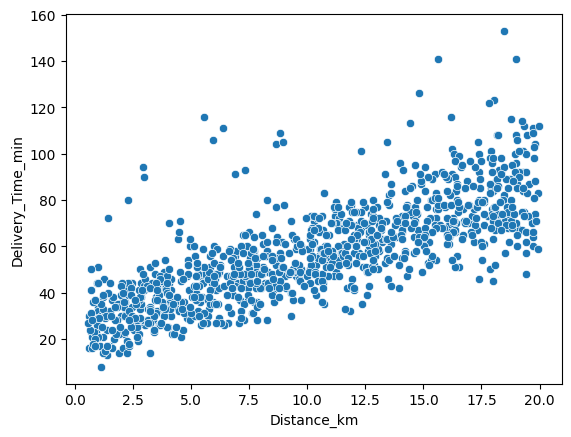

In [31]:
sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time_min',
    data=df
)
plt.show()

Step 6 Outliers

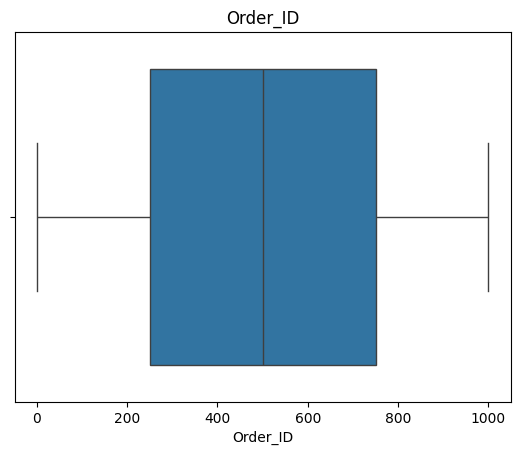

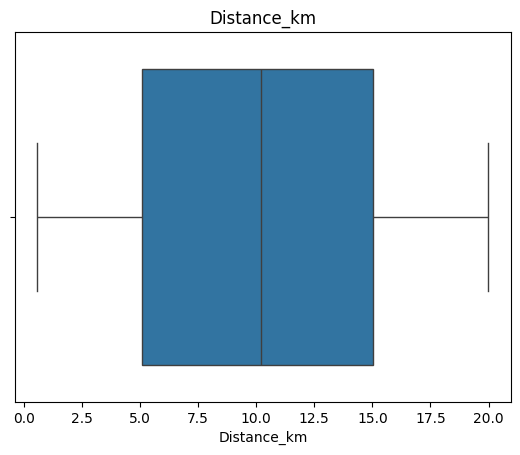

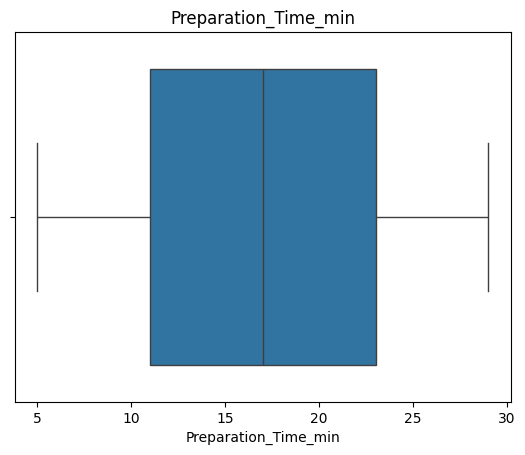

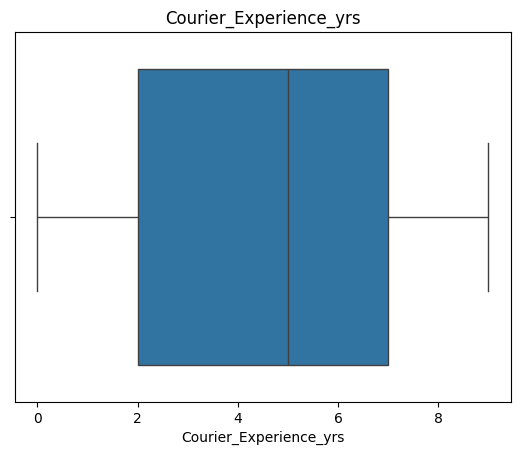

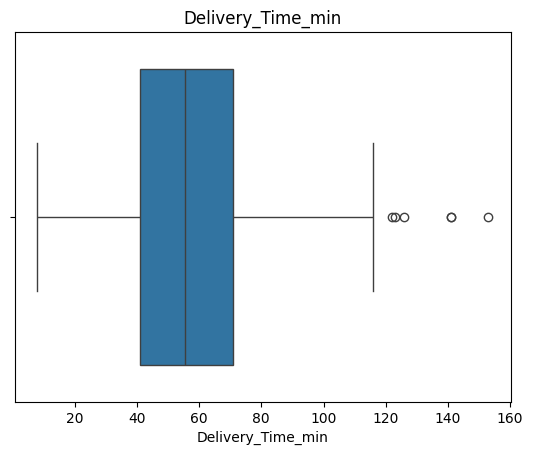

In [33]:
num_cols=df.select_dtypes(include='number').columns
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Step 7 Categorical Analysis

In [ ]:
#use to find the categorical features object data type
df.select_dtypes(include='object').columns

Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object')

In [35]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
#use get_dummies to convert categorical features into numerical features
df =pd.get_dummies(
    df,
    columns=[
        'Weather', 
        'Traffic_Level',
          'Time_of_Day', 
          'Vehicle_Type'
    ],
    drop_first=True
)

In [ ]:
df=df.astype('int')
#use to convert the data type of all columns to int

In [41]:
df.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7,12,1,43,0,0,0,1,1,0,0,0,0,0,1
1,738,16,20,2,84,0,0,0,0,0,1,1,0,0,0,0
2,741,9,28,1,59,1,0,0,0,1,0,0,0,1,0,1
3,661,7,5,1,37,0,1,0,0,0,1,0,0,0,0,1
4,412,19,16,5,68,0,0,0,0,1,0,0,1,0,0,0


In [ ]:
#used to drop the Order_ID column because it is not useful for our model
df.drop('Order_ID', axis=1, inplace=True)

In [43]:
X=df.drop('Delivery_Time_min',axis=1)
y=df['Delivery_Time_min']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_pred=model.predict(X_test)

In [47]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print('Mean Squared Error:', mse)
print('R-squared Score:', r2)

Mean Squared Error: 80.8606199983034
R-squared Score: 0.8195989431508369


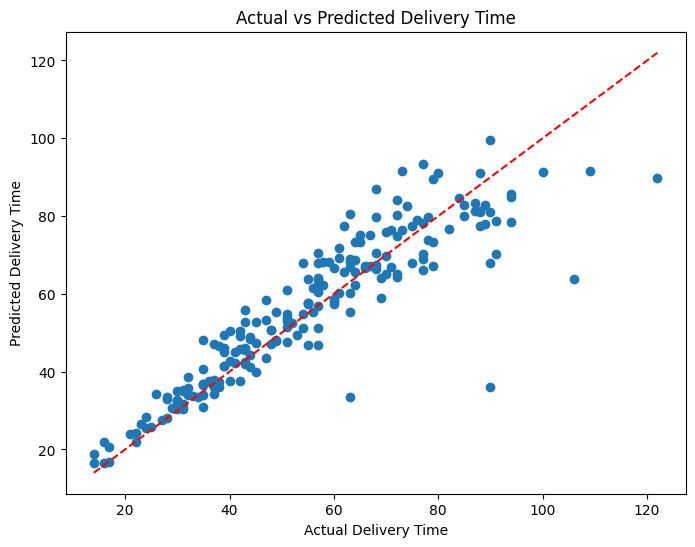

In [ ]:
#actual vs predicted plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()